In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import utils

from statsmodels.tsa.arima.model import ARIMA
from external.api_repo.generators import *
from external.api_repo.utils import *
from pmdarima.arima import ndiffs
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
boltzman= 1.38e-11
zeta = 2.24e-9

T = 300
D = (T*boltzman)/zeta
t0=0
total_time = 30
time_step = 4e-3

barrier_height=0.9e-8
left_well=3
right_well=-3
x0_mean=0
tilt=0#1e-12#2e-50
num_of_simulations=8


x,dwt=double_wells_generator(total_time=total_time, zeta=zeta,T=T,time_step=time_step,boltzmann=boltzman,right_well=right_well,left_well=left_well,
                          barrier_height=barrier_height,x0_mean=x0_mean,device=device  ,num_of_simulations=num_of_simulations,tilt=tilt)

In [24]:
x_single = x[0]
data = pd.Series(x_single.detach().cpu().numpy())

np.random.seed(0)

split = 3000
train_data=data.iloc[:split]

kpss_diffs = ndiffs(train_data, alpha=0.05, test='kpss', max_d=6)
adf_diffs = ndiffs(train_data, alpha=0.05, test='adf', max_d=6)
n_diffs = max(adf_diffs, kpss_diffs)


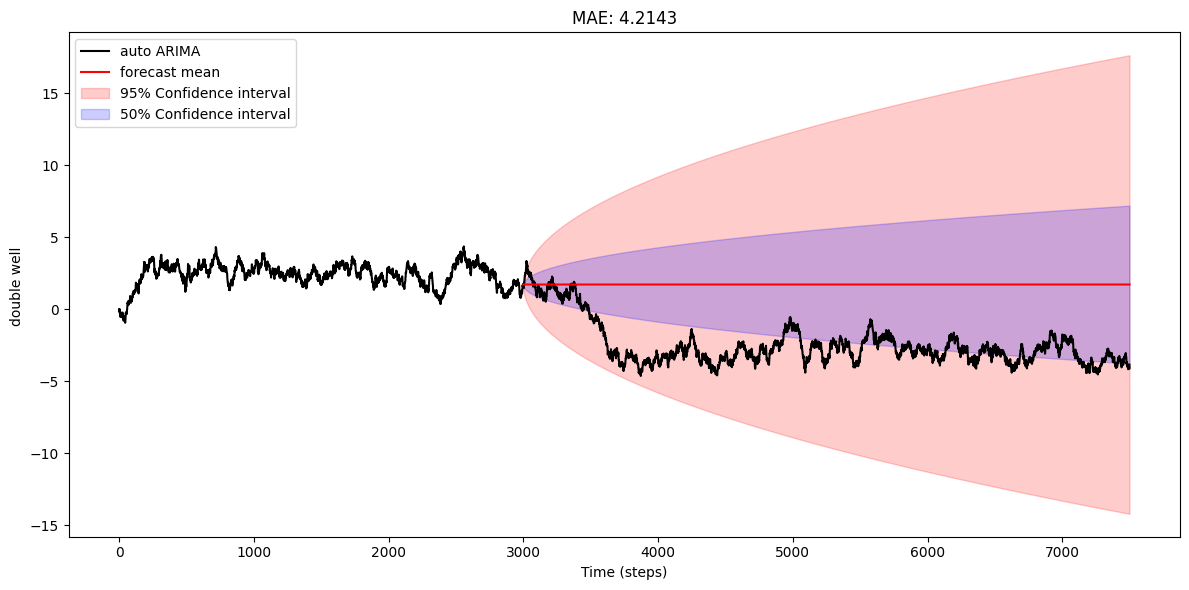

In [ ]:
model = auto_arima(
    train_data,
    seasonal=True,
    suppress_warnings=True
)

result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci = forecast_res.conf_int(alpha=0.05)
ci.index = test.index

n_sim = 10
sims = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim.index = test.index
    sims.append(sim)

plt.figure(figsize=(12, 6))

#num_trajs=4
#for _ in range(num_trajs):
#    plt.plot(data.index, x[np.random.randint(0,num_of_simulations)].detach().cpu().numpy(), color="black")    

plt.plot(data.index, data, color="black", label="auto ARIMA")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

#for sim in sims:
    #plt.plot(sim.index,sim,color="orange",alpha=0.5,label="Simulations" if n_sim == 1 else None)

plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index
plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.title(f'MAE: {mean_absolute_error(test, forecast_res.predicted_mean):.4f}')
          #\n mean MAE: {meanMAE(data.iloc[split:], sims):.4f}\n {mean_absolute_error(data.iloc[split:], sims[0]):.4f}')
plt.xlabel("Time (steps)")
plt.ylabel("double well ")
plt.legend()
plt.tight_layout()
plt.show()
